# Excercise 2a: Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [3]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

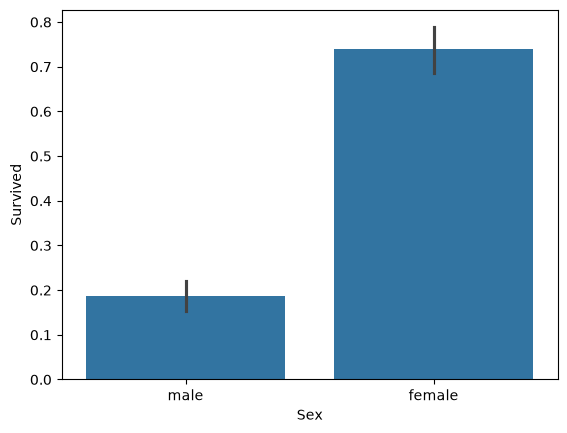

In [6]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes

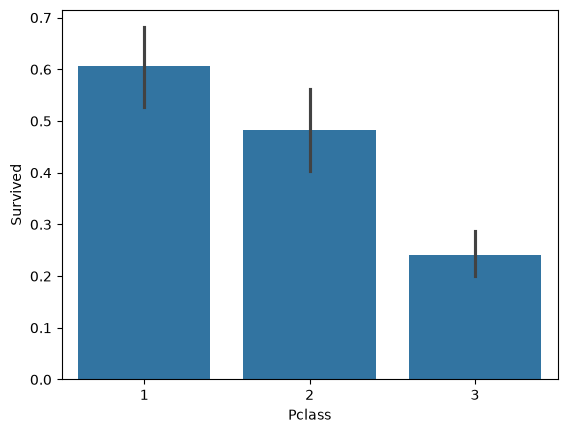

In [7]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Pclass', y='Survived', data=data)
plt.show()

# Question 2: Is survival related to Embarked?

Answer: Mabye, lookes like people whom embarked in Cherbourg survived more, this might be since the ones who embarked there had a lowe Pclass

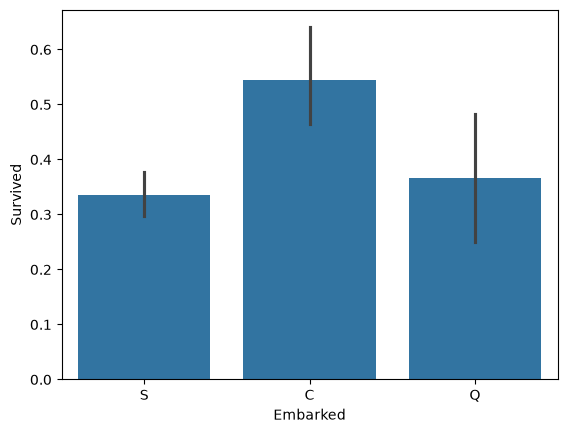

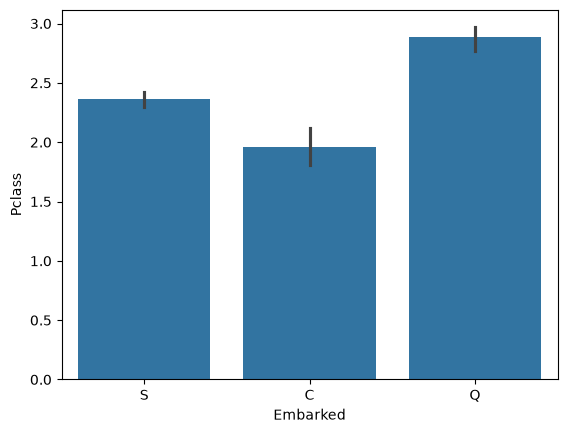

In [13]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Embarked', y='Survived', data=data)
plt.show()
sns.barplot(x='Embarked', y='Pclass', data=data)
plt.show()

# Question 3: How is age related to survival?

Answer: Overall very eaqual, but children aged 0-12 survived more.

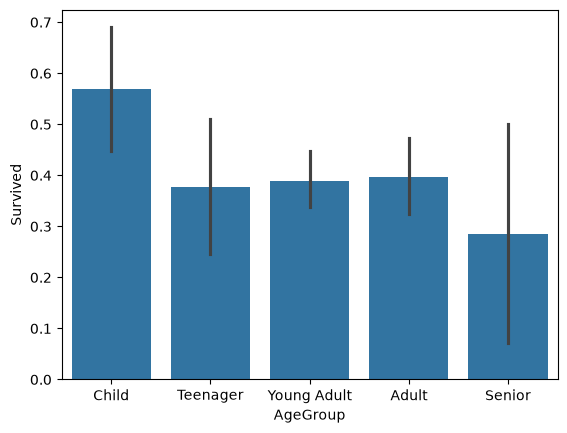

In [20]:
# Show the relevant statistics or visualization(s) to support your answer
age_groups = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])
data['AgeGroup'] = age_groups
sns.barplot(x='AgeGroup', y='Survived', data=data)
plt.show()

# Question 4: Does family size somehow affect the survival rate?

Answer: Somehow yes? Famalies up to 4people survived more, with a drastic fall on larger famalies

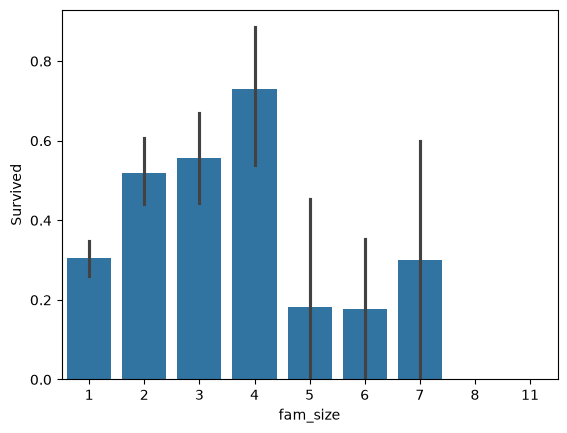

In [24]:
# Show the relevant statistics or visualization(s) to support your answer

data['fam_size'] = (data['SibSp'] + data['Parch'] + 1)
sns.barplot(x='fam_size', y='Survived', data=data)
plt.show()

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: Kinda, naturaly the "Miss" title would have higher survival rate due to priority boarding on emergancy vessels. But also the more prestigious titles would more often be in first class and thus have priority boarding.

Title
Mr          419
Miss        143
Mrs          96
Master       33
Rev           5
Dr            5
Major         2
Col           2
Mlle          2
Capt          1
Mme           1
Ms            1
Countess      1
Lady          1
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Andre\AppData\Local\Temp\ipykernel_17904\3680846799.py:2: SyntaxWarning: invalid escape sequence '\.'
  data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


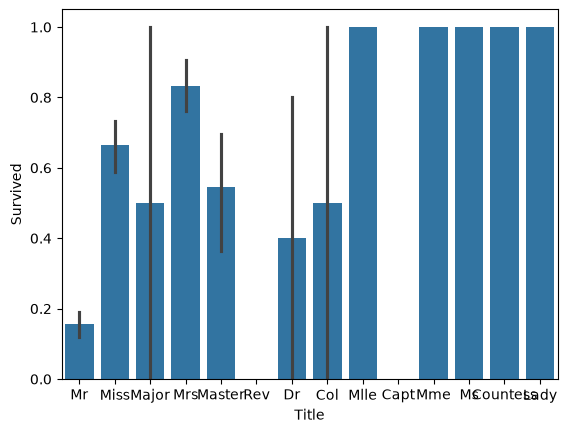

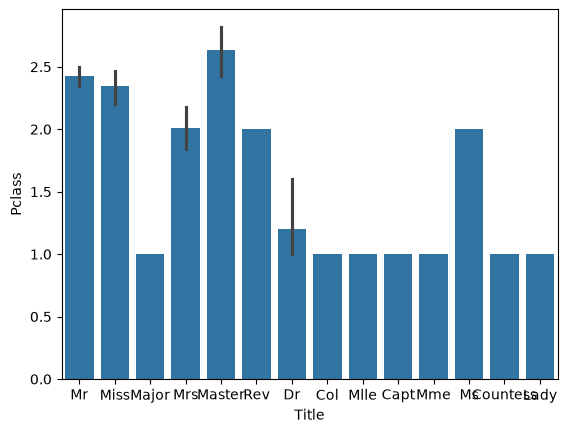

In [31]:
# Show the relevant statistics or visualization(s) to support your answer
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(data['Title'].value_counts())


sns.barplot(x='Title', y='Survived', data=data)
plt.show()
sns.barplot(x='Title', y='Pclass', data=data)
plt.show()